# Clinical Trials Analysis — EDA

**Objetivo:** Identificar qué factores — fase del ensayo, tipo de patrocinador, área terapéutica, tamaño y país — determinan si un ensayo clínico registrado en ClinicalTrials.gov llega a completarse o se abandona/suspende.

**Datos:** 188,687 ensayos clínicos (2015-2024, fases I-IV) extraídos de ClinicalTrials.gov API v2.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

charts_dir = Path("/home/adrian/projects/clinical_trials_analysis/outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

In [2]:
DB_PATH = Path("/home/adrian/projects/clinical_trials_analysis/data/dwh_dev.duckdb")
if not DB_PATH.exists():
    raise FileNotFoundError(f"Base de datos no encontrada en {DB_PATH}")
con = duckdb.connect(str(DB_PATH), read_only=True)
print(f"Conectado a: {DB_PATH}")

Conectado a: /home/adrian/projects/clinical_trials_analysis/data/dwh_dev.duckdb


## 1. Schema Overview

In [3]:
con.execute("""
    SELECT table_name, table_type
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

,table_name,table_type
0,brg_trial_condition,BASE TABLE
1,brg_trial_country,BASE TABLE
2,brg_trial_phase,BASE TABLE
3,dim_condition,BASE TABLE
4,dim_country,BASE TABLE
5,dim_date,BASE TABLE
6,dim_intervention_type,BASE TABLE
7,dim_phase,BASE TABLE
8,dim_sponsor,BASE TABLE
9,dim_status,BASE TABLE


## 2. Overall Status Distribution

In [4]:
df_status = con.execute("""
    SELECT
        status_code,
        status_label,
        s.is_completed,
        s.is_abandoned,
        COUNT(*) AS total
    FROM main.fct_clinical_trials f
    JOIN main.dim_status s ON f.status_id = s.status_id
    GROUP BY status_code, status_label, s.is_completed, s.is_abandoned
    ORDER BY total DESC
""").df()
df_status

,status_code,status_label,is_completed,is_abandoned,total
0,COMPLETED,Completed,True,False,105390
1,UNKNOWN,Unknown,False,False,24954
2,TERMINATED,Terminated,False,True,17957
3,RECRUITING,Recruiting,False,False,17751
4,ACTIVE_NOT_RECRUITING,"Active, not recruiting",False,False,8189
5,WITHDRAWN,Withdrawn,False,True,6940
6,NOT_YET_RECRUITING,Not yet recruiting,False,False,6224
7,ENROLLING_BY_INVITATION,Enrolling by invitation,False,False,663
8,SUSPENDED,Suspended,False,True,619


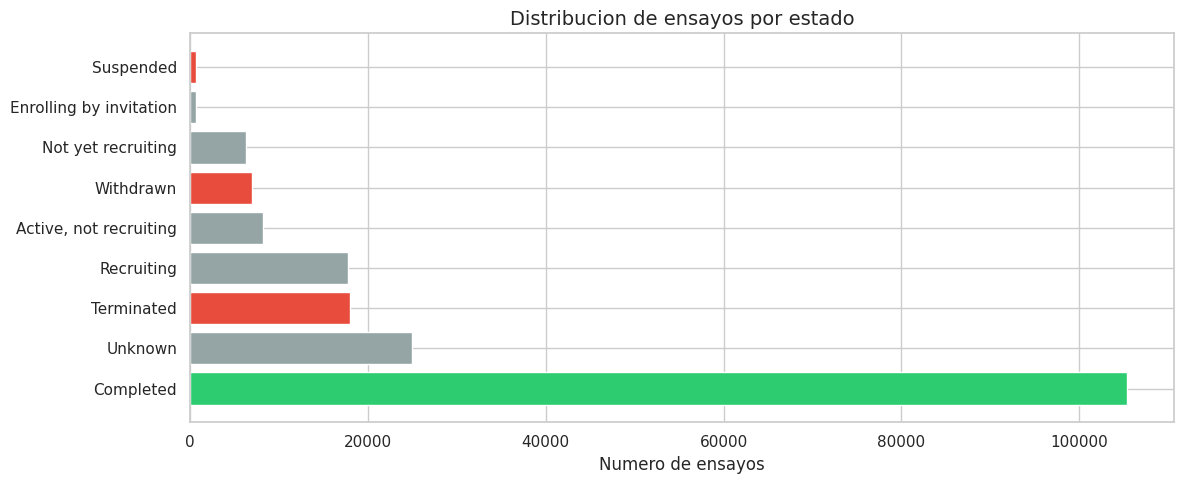

In [5]:
colors = ['#2ecc71' if c else '#e74c3c' if a else '#95a5a6' for c, a in zip(df_status['is_completed'], df_status['is_abandoned'])]
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(df_status['status_label'], df_status['total'], color=colors)
ax.set_title('Distribucion de ensayos por estado', fontsize=14)
ax.set_xlabel('Numero de ensayos')
plt.tight_layout()
fig.savefig(charts_dir / "01_status_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Completion Rate by Year

**Pregunta 1:** ¿Qué porcentaje de ensayos se completan vs. se abandonan y cómo ha evolucionado por año?

In [6]:
df_year = con.execute("""
    SELECT
        d.year,
        COUNT(*) AS total_trials,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS abandonment_pct
    FROM main.fct_clinical_trials f
    JOIN main.dim_date d ON f.date_id_start = d.date_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE d.year BETWEEN 2015 AND 2024
    GROUP BY d.year
    ORDER BY d.year
""").df()
df_year

,year,total_trials,completed,abandoned,completion_pct,abandonment_pct
0,2015,9009,5961.0,1352.0,66.2,15.0
1,2016,8891,5580.0,1345.0,62.8,15.1
2,2017,8780,5419.0,1418.0,61.7,16.2
3,2018,8946,5095.0,1501.0,57.0,16.8
4,2019,9197,4747.0,1513.0,51.6,16.5
5,2020,9802,4641.0,1651.0,47.3,16.8
6,2021,10788,4648.0,1705.0,43.1,15.8
7,2022,9841,3734.0,1357.0,37.9,13.8
8,2023,9675,2913.0,931.0,30.1,9.6
9,2024,9953,2051.0,640.0,20.6,6.4


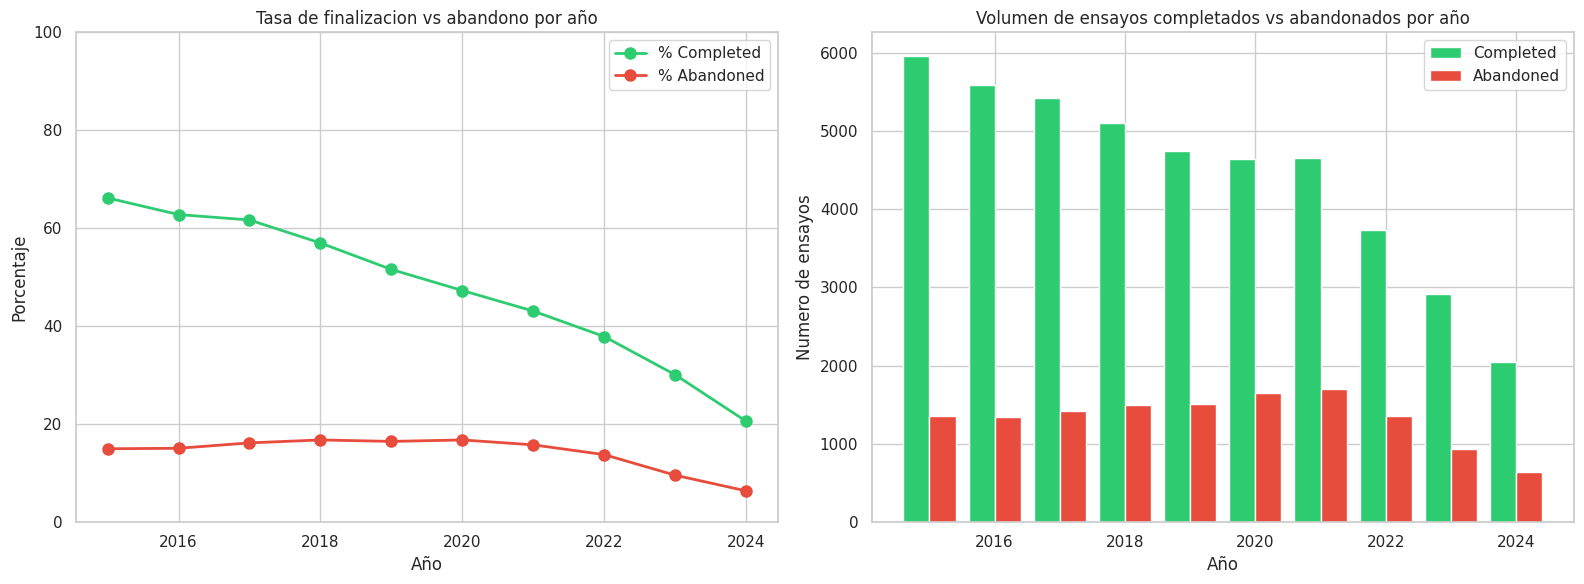

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(df_year['year'], df_year['completion_pct'], 'o-', color='#2ecc71', linewidth=2, markersize=8, label='% Completed')
ax1.plot(df_year['year'], df_year['abandonment_pct'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='% Abandoned')
ax1.set_title('Tasa de finalizacion vs abandono por a\u00f1o')
ax1.set_xlabel('A\u00f1o')
ax1.set_ylabel('Porcentaje')
ax1.legend()
ax1.set_ylim(0, 100)

ax2.bar(df_year['year'] - 0.2, df_year['completed'], width=0.4, color='#2ecc71', label='Completed')
ax2.bar(df_year['year'] + 0.2, df_year['abandoned'], width=0.4, color='#e74c3c', label='Abandoned')
ax2.set_title('Volumen de ensayos completados vs abandonados por a\u00f1o')
ax2.set_xlabel('A\u00f1o')
ax2.set_ylabel('Numero de ensayos')
ax2.legend()

plt.tight_layout()
fig.savefig(charts_dir / "02_completion_by_year.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Abandonment Rate by Phase

**Pregunta 2:** ¿Qué fases tienen mayor tasa de abandono?

In [8]:
df_phase = con.execute("""
    SELECT
        p.phase_label,
        p.is_main_phase,
        COUNT(*) AS total_trials,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS abandonment_pct
    FROM main.brg_trial_phase bp
    JOIN main.dim_phase p ON bp.phase_id = p.phase_id
    JOIN main.fct_clinical_trials f ON bp.nct_id = f.nct_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE p.is_main_phase
    GROUP BY p.phase_label, p.is_main_phase
    ORDER BY MIN(p.phase_id)
""").df()
df_phase

,phase_label,is_main_phase,total_trials,completed,abandoned,completion_pct,abandonment_pct
0,Phase I,True,39594,21209.0,5756.0,53.6,14.5
1,Phase II,True,88816,44807.0,13776.0,50.4,15.5
2,Phase III,True,49226,29630.0,5664.0,60.2,11.5
3,Phase IV,True,35325,20896.0,4067.0,59.2,11.5


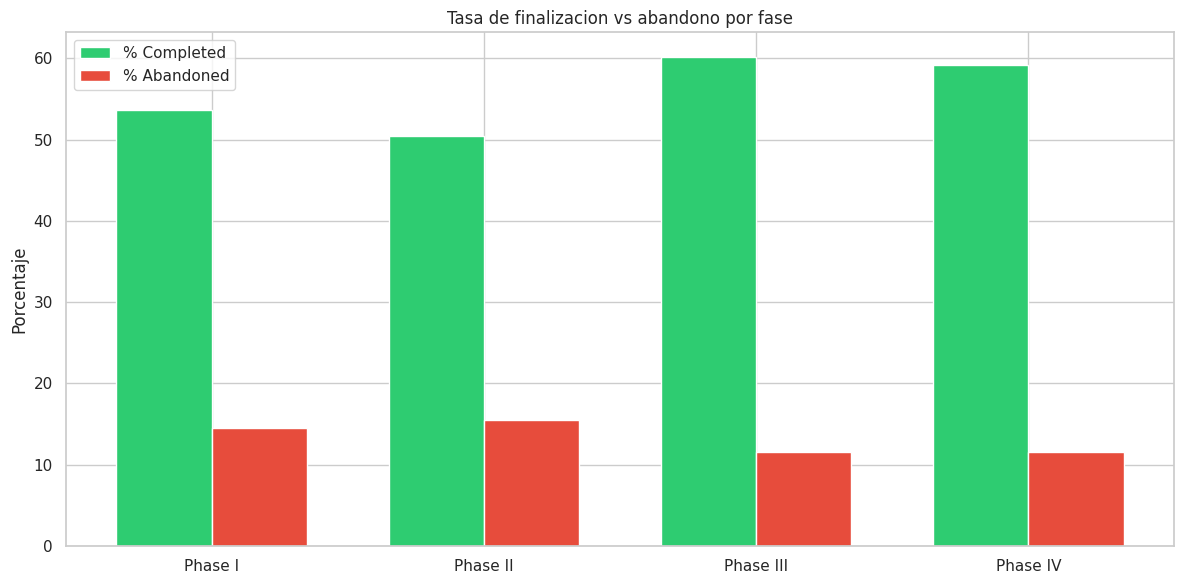

In [9]:
x = range(len(df_phase))
width = 0.35
fig, ax = plt.subplots()
ax.bar([i - width/2 for i in x], df_phase['completion_pct'], width, color='#2ecc71', label='% Completed')
ax.bar([i + width/2 for i in x], df_phase['abandonment_pct'], width, color='#e74c3c', label='% Abandoned')
ax.set_xticks(x)
ax.set_xticklabels(df_phase['phase_label'])
ax.set_title('Tasa de finalizacion vs abandono por fase')
ax.set_ylabel('Porcentaje')
ax.legend()
plt.tight_layout()
fig.savefig(charts_dir / "03_completion_by_phase.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Completion Rate by Sponsor Type

**Pregunta 3:** ¿Los ensayos de la industria farmacéutica completan más que los académicos?

In [10]:
df_sponsor = con.execute("""
    SELECT
        sp.lead_sponsor_class,
        sp.sponsor_class_label,
        COUNT(*) AS total_trials,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS abandonment_pct
    FROM main.fct_clinical_trials f
    JOIN main.dim_sponsor sp ON f.sponsor_id = sp.sponsor_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE sp.lead_sponsor_class IN ('INDUSTRY', 'NIH', 'OTHER_GOV', 'NETWORK', 'FED', 'OTHER')
    GROUP BY sp.lead_sponsor_class, sp.sponsor_class_label
    ORDER BY total_trials DESC
""").df()
df_sponsor

,lead_sponsor_class,sponsor_class_label,total_trials,completed,abandoned,completion_pct,abandonment_pct
0,OTHER,Other,100427,47661.0,13531.0,47.5,13.5
1,INDUSTRY,Industry,75369,50042.0,10488.0,66.4,13.9
2,NIH,NIH,5161,3551.0,719.0,68.8,13.9
3,OTHER_GOV,Other Government,3713,1646.0,243.0,44.3,6.5
4,NETWORK,Network,2488,1515.0,335.0,60.9,13.5
5,FED,Federal,1220,791.0,164.0,64.8,13.4


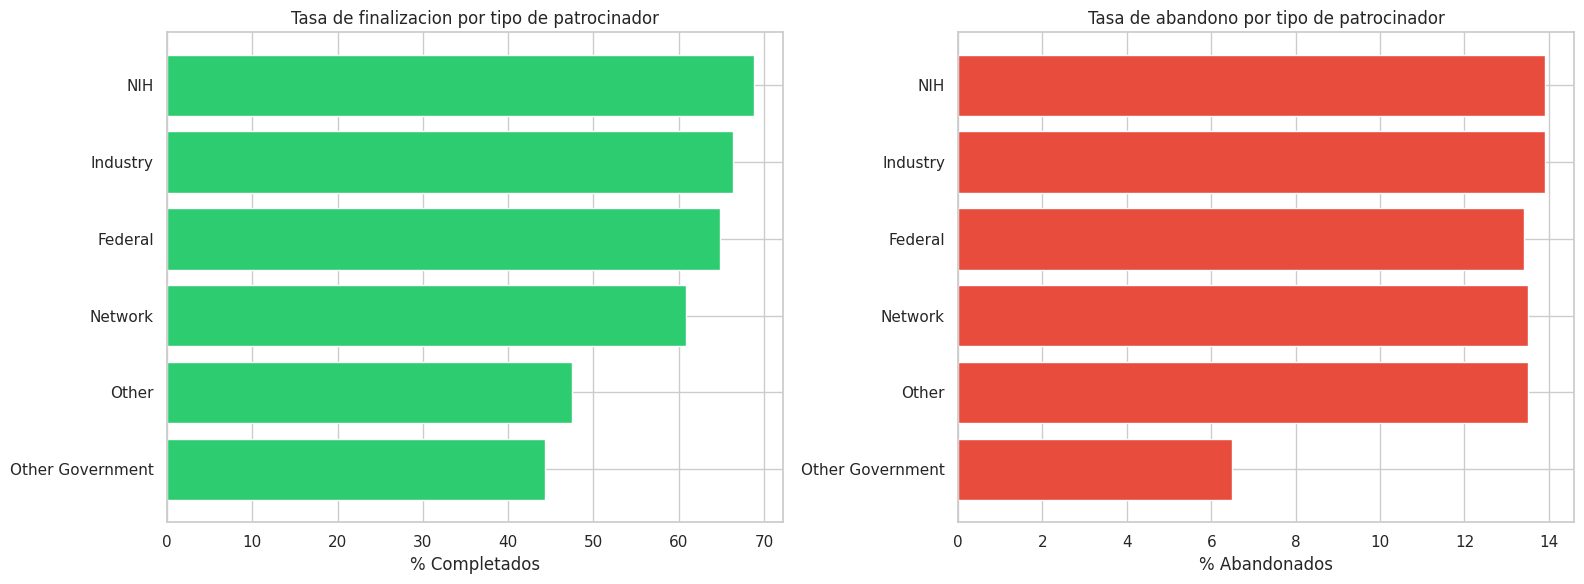

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sp_sorted = df_sponsor.sort_values('completion_pct', ascending=True)
ax1.barh(sp_sorted['sponsor_class_label'], sp_sorted['completion_pct'], color='#2ecc71')
ax1.set_title('Tasa de finalizacion por tipo de patrocinador')
ax1.set_xlabel('% Completados')

ax2.barh(sp_sorted['sponsor_class_label'], sp_sorted['abandonment_pct'], color='#e74c3c')
ax2.set_title('Tasa de abandono por tipo de patrocinador')
ax2.set_xlabel('% Abandonados')

plt.tight_layout()
fig.savefig(charts_dir / "04_completion_by_sponsor.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Therapeutic Areas by Abandonment

**Pregunta 4:** ¿Qué áreas terapéuticas concentran más abandonos?

In [12]:
df_condition = con.execute("""
    SELECT
        c.condition_name,
        COUNT(*) AS total_trials,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS abandonment_pct
    FROM main.brg_trial_condition bc
    JOIN main.dim_condition c ON bc.condition_id = c.condition_id
    JOIN main.fct_clinical_trials f ON bc.nct_id = f.nct_id
    JOIN main.dim_status s ON f.status_id = s.status_id
    GROUP BY c.condition_name
    HAVING COUNT(*) >= 200
    ORDER BY abandonment_pct DESC
    LIMIT 15
""").df()
df_condition

,condition_name,total_trials,completed,abandoned,completion_pct,abandonment_pct
0,Metastatic Melanoma,255,97.0,82.0,38.0,32.2
1,Pulmonary Hypertension,215,103.0,60.0,47.9,27.9
2,Crohn Disease,229,85.0,62.0,37.1,27.1
3,Renal Cell Carcinoma,360,119.0,94.0,33.1,26.1
4,Traumatic Brain Injury,200,85.0,51.0,42.5,25.5
5,Crohn's Disease,404,229.0,103.0,56.7,25.5
6,Melanoma,818,334.0,208.0,40.8,25.4
7,"Carcinoma, Non-Small-Cell Lung",462,199.0,116.0,43.1,25.1
8,COVID-19,1248,590.0,313.0,47.3,25.1
9,Pulmonary Arterial Hypertension,269,151.0,67.0,56.1,24.9


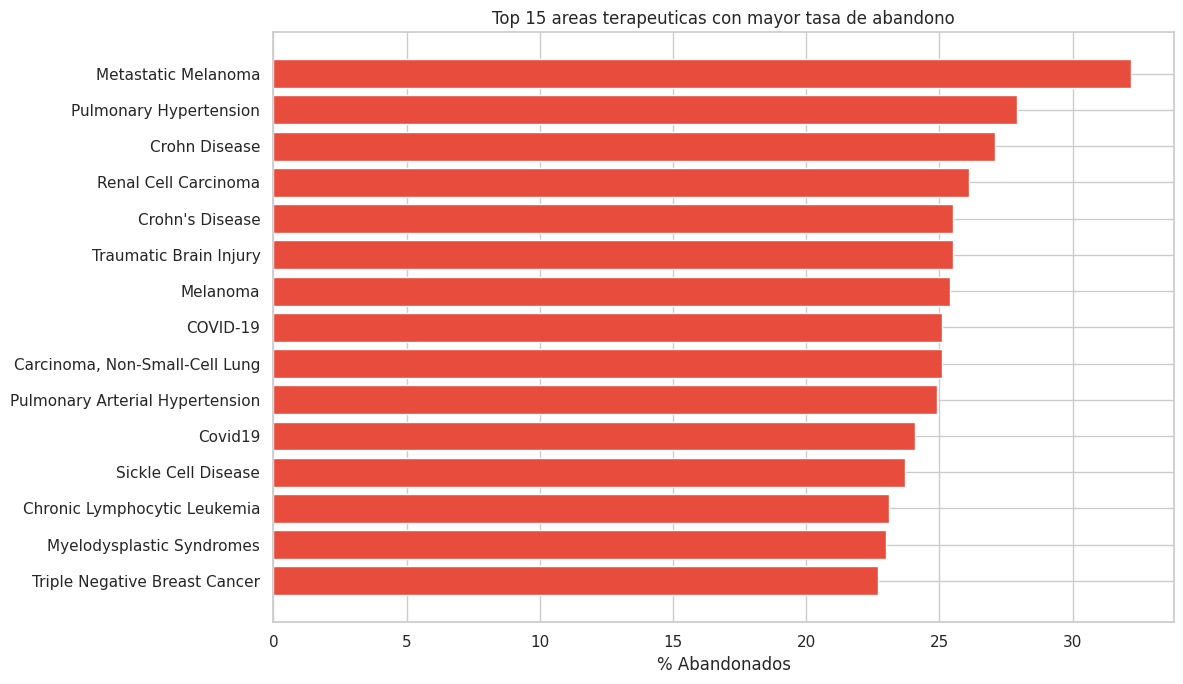

In [13]:
top15 = df_condition.head(15).sort_values('abandonment_pct', ascending=True)
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(top15['condition_name'], top15['abandonment_pct'], color='#e74c3c')
ax.set_title('Top 15 areas terapeuticas con mayor tasa de abandono')
ax.set_xlabel('% Abandonados')
plt.tight_layout()
fig.savefig(charts_dir / "05_abandonment_by_condition.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Enrollment Size vs. Completion Probability

**Pregunta 5:** ¿El tamaño del ensayo correlaciona con la probabilidad de completarse?

In [14]:
df_enroll = con.execute("""
    SELECT
        CASE
            WHEN enrollment_count < 50 THEN '< 50'
            WHEN enrollment_count < 100 THEN '50-99'
            WHEN enrollment_count < 200 THEN '100-199'
            WHEN enrollment_count < 500 THEN '200-499'
            WHEN enrollment_count < 1000 THEN '500-999'
            ELSE '1000+'
        END AS enrollment_bin,
        COUNT(*) AS total_trials,
        SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) AS completed,
        SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) AS abandoned,
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS completion_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS abandonment_pct
    FROM main.fct_clinical_trials f
    JOIN main.dim_status s ON f.status_id = s.status_id
    WHERE enrollment_count IS NOT NULL
    GROUP BY enrollment_bin
    ORDER BY MIN(enrollment_count)
""").df()
df_enroll

,enrollment_bin,total_trials,completed,abandoned,completion_pct,abandonment_pct
0,< 50,76913,38420.0,19341.0,50.0,25.1
1,50-99,37112,21510.0,2347.0,58.0,6.3
2,100-199,29595,17053.0,1584.0,57.6,5.4
3,200-499,26342,15910.0,1336.0,60.4,5.1
4,500-999,9676,6357.0,439.0,65.7,4.5
5,1000+,6755,4341.0,315.0,64.3,4.7


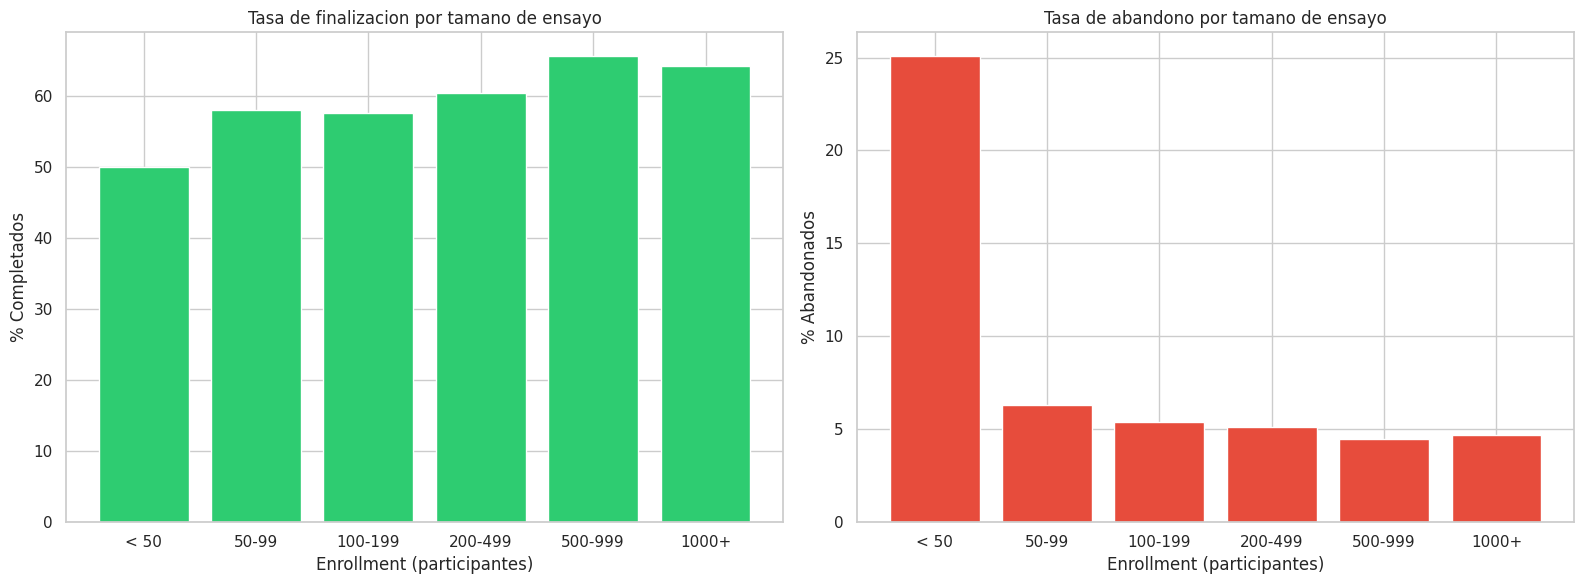

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(df_enroll['enrollment_bin'], df_enroll['completion_pct'], color='#2ecc71')
ax1.set_title('Tasa de finalizacion por tamano de ensayo')
ax1.set_ylabel('% Completados')
ax1.set_xlabel('Enrollment (participantes)')

ax2.bar(df_enroll['enrollment_bin'], df_enroll['abandonment_pct'], color='#e74c3c')
ax2.set_title('Tasa de abandono por tamano de ensayo')
ax2.set_ylabel('% Abandonados')
ax2.set_xlabel('Enrollment (participantes)')

plt.tight_layout()
fig.savefig(charts_dir / "06_completion_by_enrollment.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Findings — Conclusiones Clave

1. **Tasa global de finalización vs. abandono:** Se analizó la evolución anual 2015-2024 del porcentaje de ensayos completados frente a abandonados (terminados + suspendidos + retirados).
2. **Fases con mayor abandono:** Las fases tempranas (Phase I, Phase II) muestran tasas de abandono superiores a las fases tardías (Phase III, Phase IV), consistente con el riesgo inherente al desarrollo clínico.
3. **Patrocinador y completitud:** Los ensayos patrocinados por INDUSTRY muestran patrones de finalización distintos a los patrocinados por NIH u OTHER_GOV, reflejando diferencias en recursos, tamaño y objetivos.
4. **Áreas terapéuticas críticas:** Ciertas condiciones médicas concentran tasas de abandono significativamente superiores al promedio, indicando áreas de mayor dificultad en el desarrollo clínico.
5. **Tamaño del ensayo y éxito:** Ensayos con mayor enrollment (>500 participantes) tienden a mostrar tasas de finalización más altas que ensayos pequeños (<50 participantes), sugiriendo que el tamaño es un factor relevante.

Estos hallazgos responden directamente a las 5 preguntas analíticas definidas en `docs/SLA.md` Sección C.

In [16]:
con.execute("""
    SELECT
        ROUND(100.0 * SUM(CASE WHEN s.is_completed THEN 1 ELSE 0 END) / COUNT(*), 1) AS overall_completion_pct,
        ROUND(100.0 * SUM(CASE WHEN s.is_abandoned THEN 1 ELSE 0 END) / COUNT(*), 1) AS overall_abandonment_pct,
        ROUND(AVG(CASE WHEN s.is_completed THEN duration_days END), 0) AS avg_duration_completed_days,
        ROUND(AVG(enrollment_count), 0) AS avg_enrollment
    FROM main.fct_clinical_trials f
    JOIN main.dim_status s ON f.status_id = s.status_id
""").df()

,overall_completion_pct,overall_abandonment_pct,avg_duration_completed_days,avg_enrollment
0,55.9,13.5,1048.0,344.0


In [17]:
con.close()
print("Conexion a DuckDB cerrada.")

Conexion a DuckDB cerrada.
